#Module 2 - Assignment 2

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = sns.load_dataset("taxis")

In [ ]:
df

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [ ]:
# understanding the data:
df.head()

In [ ]:
df.tail()

In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
df.info()

In [ ]:
df.describe()

#2) Handling Missing Values

In [ ]:
df.isna().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


In [ ]:
df['payment'].fillna(df['payment'].mode()[0],inplace = True)

In [ ]:
df['dropoff_zone'].fillna(df['dropoff_zone'].mode()[0],inplace = True)

In [ ]:
df['pickup_zone'].fillna(df['pickup_zone'].mode()[0], inplace = True)

In [ ]:
df['pickup_borough'].fillna(df['pickup_borough'].mode()[0], inplace = True)

In [ ]:
df['dropoff_borough'].fillna(df['dropoff_borough'].mode()[0], inplace  = True)

In [ ]:
df.isna().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,0


#3) Visualizations using Matplotlib/Pandas Plot:

Line Chart: Plot a line chart to visualize the fare over time, using the pickup timestamp as the x-axis and fare as the y-axis. Ensure the pickup column is converted to a datetime
format before plotting.

In [ ]:
# Convert datetime of pick column
df['pickup'] = pd.to_datetime(df['pickup'])

In [ ]:
# Extract only date from pick column:
df['pickup_date'] = df['pickup'].dt.date

In [ ]:
fare_over_time = df.groupby('pickup_date')['fare'].mean().reset_index()

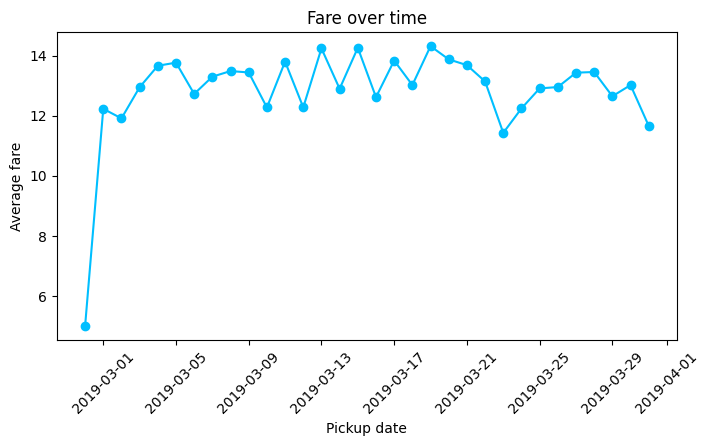

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(fare_over_time['pickup_date'],
         fare_over_time['fare'],
         marker='o',
         color='deepskyblue',
         linestyle='-')

plt.title('Fare over time')
plt.xlabel('Pickup date')
plt.ylabel('Average fare')
plt.xticks(rotation = 45)
plt.show()

Bar Chart  
Create a bar chart to show the total fare for each pickup_borough. Group the data
by pickup_borough and sum the fare for each group.

In [ ]:
Total_fare = df.groupby('pickup_borough')['fare'].sum().reset_index()

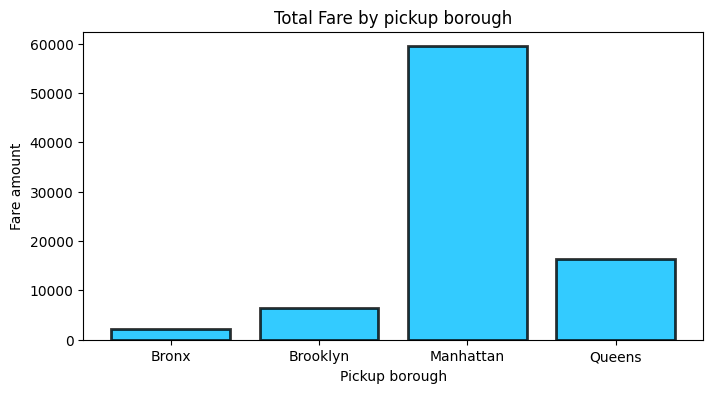

In [ ]:
plt.figure(figsize = (8,4))

plt.bar(Total_fare['pickup_borough'],
         Total_fare['fare'],
         color = 'deepskyblue',
         edgecolor = 'black',
         linewidth = 2,
         align = 'center',
         alpha = 0.8)

plt.title('Total Fare by pickup borough')
plt.xlabel('Pickup borough')
plt.ylabel('Fare amount')
plt.show()

Pie Chart  
Plot a pie chart showing the distribution of trips based on the payment method (credit
card, cash, etc.). Each slice should represent the count of trips for a specific payment
method.

In [ ]:
payment_counts = df['payment'].value_counts()

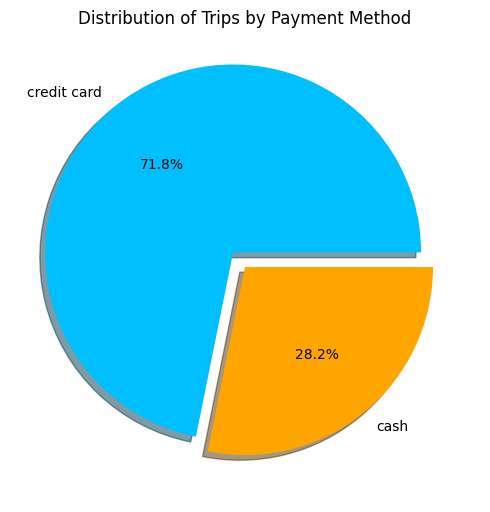

In [ ]:
plt.figure(figsize=(10,5))

plt.pie(payment_counts,
        labels=payment_counts.index,
        colors=['deepskyblue','orange'],
        autopct='%1.1f%%',
        shadow = True,
        explode=[0.1,0])

plt.tight_layout()
plt.title('Distribution of Trips by Payment Method')
plt.show()

Histogram  
Create a histogram to visualize the distribution of distance. Customize the number of
bins for better granularity and ensure the plot is easy to interpret.

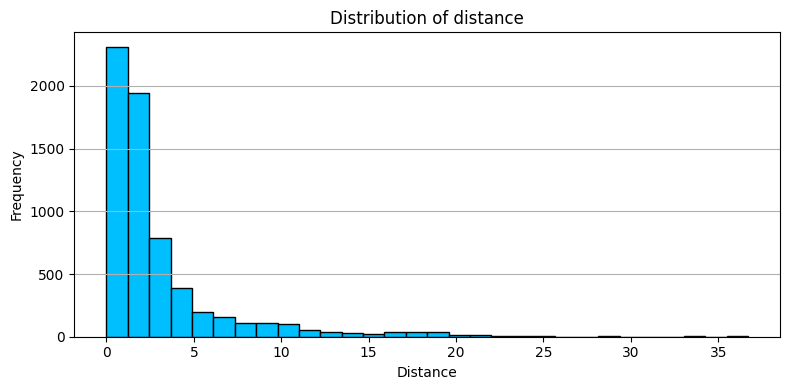

In [ ]:
plt.figure(figsize=(8,4))

plt.hist(df['distance'],bins = 30,
         color='deepskyblue',
         edgecolor = 'black')

plt.title('Distribution of distance')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Box Plot  
Plot a box plot to visualize the distribution of tip amounts for each pickup_borough.
Use pickup_borough as the categorical axis and tip as the numeric axis.

<Figure size 1000x500 with 0 Axes>

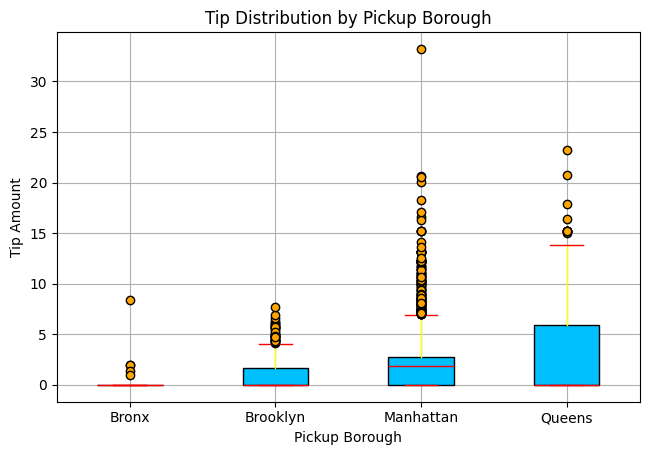

In [ ]:
plt.figure(figsize=(10,5))

df.boxplot(column='tip',
           by='pickup_borough',
           patch_artist = True,
           boxprops = dict(facecolor = 'deepskyblue', color = 'black'),
           medianprops = dict(color = 'red'),
           whiskerprops = dict(color = 'yellow'),
           capprops = dict(color = 'red'),
           flierprops = dict(marker = 'o',markerfacecolor = 'orange'))

plt.title("Tip Distribution by Pickup Borough")
plt.suptitle("")
plt.xlabel("Pickup Borough")
plt.tight_layout()
plt.ylabel("Tip Amount")
plt.show()

#Visualizations using Seaborn:

Count Plot  
Create a count plot to visualize the number of trips in each pickup_borough. The
x-axis should represent the boroughs, and the y-axis should show the count of trips.

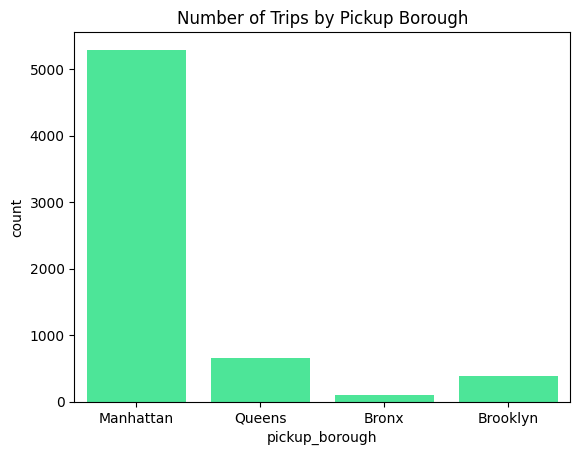

In [ ]:
sns.countplot(
    x = 'pickup_borough',
    data = df,
    color = 'springgreen',
    alpha = 0.8
)

plt.title('Number of Trips by Pickup Borough')
plt.show()

Scatter Plot  
Plot a scatter plot to show the relationship between distance and fare. Use
distance on the x-axis and fare on the y-axis to visualize any correlation. Color the
points based on the pickup_borough to differentiate the trips by their respective
boroughs.

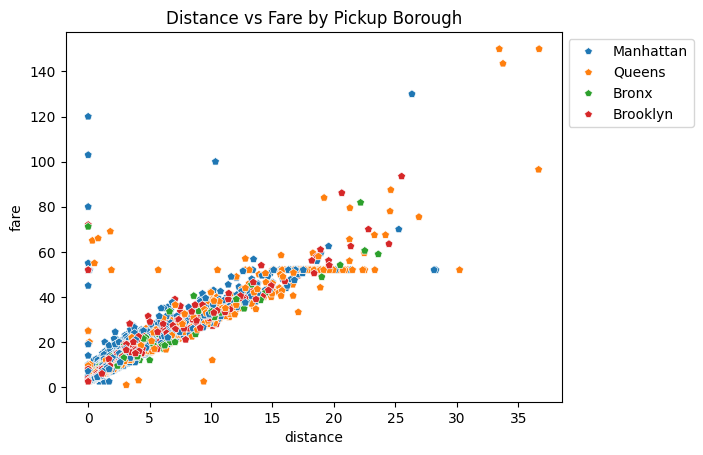

In [ ]:
sns.scatterplot(x = 'distance',
                y = 'fare',
                data = df,
                color = 'springgreen',
                hue='pickup_borough',
                marker = 'p')

plt.title("Distance vs Fare by Pickup Borough")
plt.legend(bbox_to_anchor=(1,1))
plt.show()

Heatmap  
Plot a heatmap to visualize the correlation between numerical variables such as
distance, fare, tip, tolls, and total. Use a correlation matrix to highlight the
relationships.

In [ ]:
num_data = df[['distance', 'fare', 'tip', 'tolls', 'total']]
corr_matrix = num_data.corr()
corr_matrix

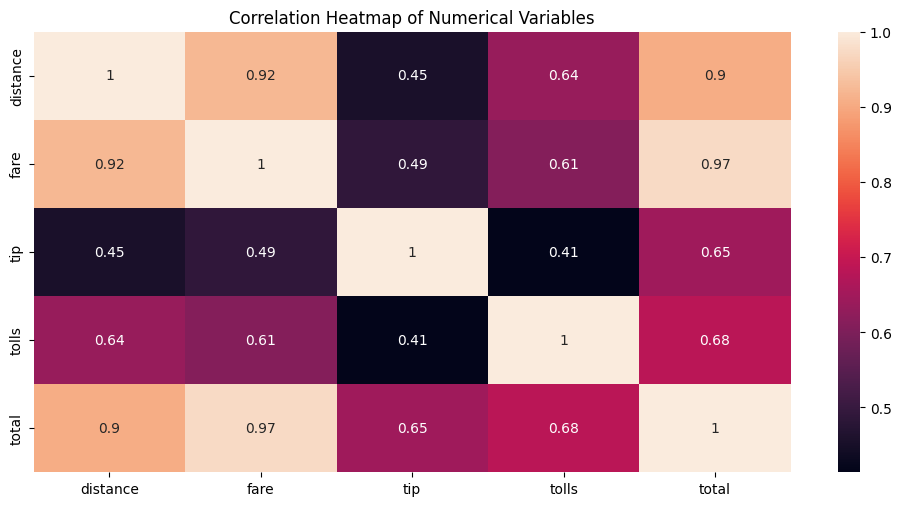

In [ ]:
plt.figure(figsize=(10,5))

sns.heatmap(corr_matrix,annot = True)

plt.tight_layout()
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

Pair Plot  
Create a pair plot to visualize the pairwise relationships between distance, fare, tip,
and total. Color the data points according to the pickup_zone method to compare
how different zones affect these variables.

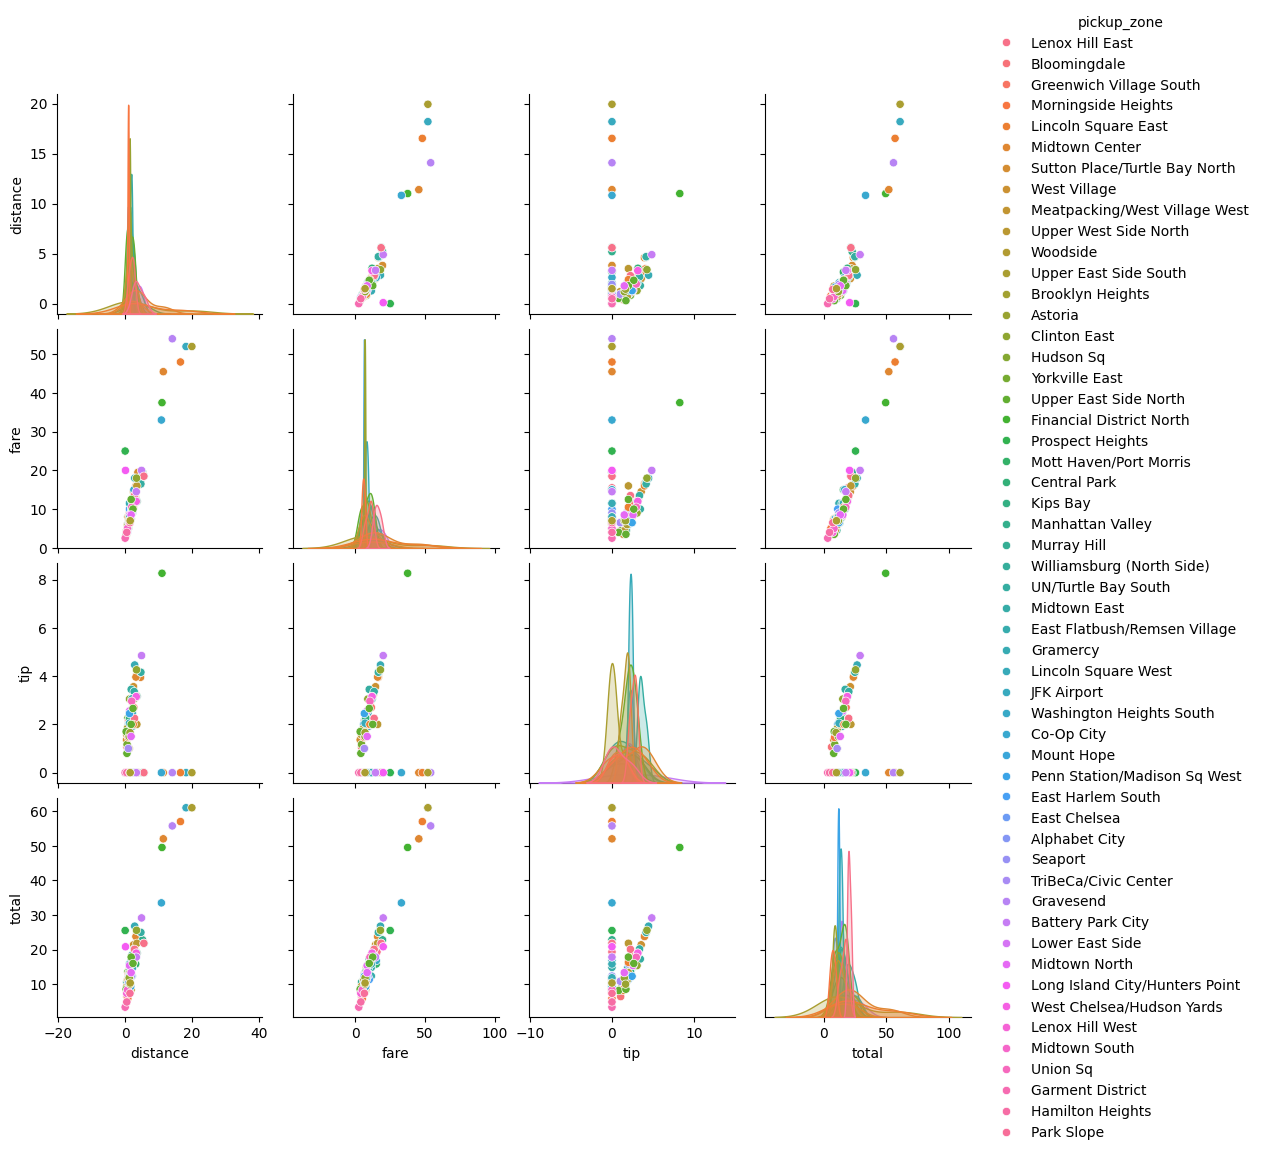

In [ ]:
sample_df = df.sample(100)

sns.pairplot(
    sample_df,
    vars=['distance', 'fare', 'tip', 'total'],
    hue='pickup_zone'
)

plt.show()

Violin Plot  
Plot a violin plot to show the distribution of fare for each payment method. Use the
payment method as the categorical axis and fare as the numeric axis to visualize its
distribution.

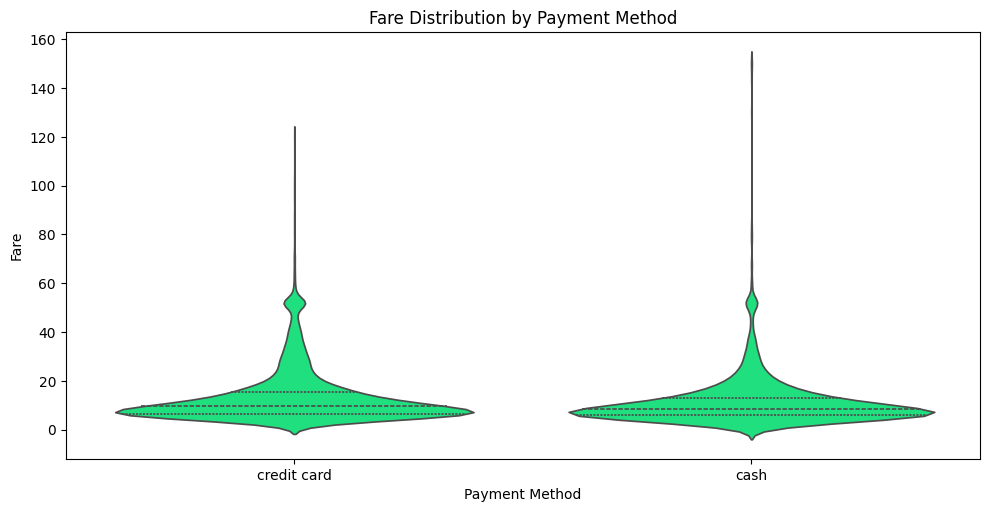

In [ ]:
plt.figure(figsize=(10,5))

sns.violinplot(
    data=df,
    x='payment',
    y='fare',
    color = 'springgreen',
    inner = 'quartile'
)

plt.tight_layout()
plt.xlabel('Payment Method')
plt.ylabel('Fare')
plt.title('Fare Distribution by Payment Method')
plt.show()